# RealMLP XAI study notebook

This notebook is a model-specific XAI study for the saved 10-fold RealMLP checkpoint family reconstructed from `churn_analysis_helpers.py`.

The focus is not merely to replay predictions. The focus is to understand the model's smooth nonlinear response geometry, feature sensitivity, and where that geometry helps or fails.

## Study perspective

We treat the fitted predictor as an ensemble-averaged neural probability map:
$$
p_{\text{mlp}}(x) = \frac{1}{K}\sum_{k=1}^{K}\operatorname{softmax}\!\big(g_k(\phi_{\text{num}}(x_{\text{num}}), \phi_{\text{cat}}(x_{\text{cat}}))\big)_1.
$$

Unlike the tree model, the RealMLP combines:
- robust smooth-clipped numerical scaling,
- periodic numerical embeddings,
- one-hot and learnt categorical embeddings,
- stacked GELU nonlinearities,
- fold-model averaging.

The central XAI questions are therefore:

1. Which variables drive the ensemble's global behaviour?
2. Where is the response surface smooth, sharp, or unstable?
3. Which cases create member disagreement?
4. Which inputs move the model most under local perturbation or ablation?

## Required files in `./`

- `train.csv`
- `test.csv`
- `realmlp_fold_*.pth`
- `churn_analysis_helpers.py`


In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import shap

from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from sklearn.inspection import permutation_importance

from churn_analysis_helpers import (
    CFG,
    seed_everything,
    setup_plotting,
    ensure_output_dir,
    savefig,
    build_feature_frames,
    prepare_realmlp_frames,
    inspect_realmlp_schema,
    replay_realmlp,
    make_decile_frame,
    cumulative_capture,
    FE_realmlp,
    RobustScaleSmoothClipTransform,
    RealMLP,
    load_realmlp_checkpoints,
)
from sklearn.preprocessing import TargetEncoder

seed_everything(67)
setup_plotting()

cfg = CFG()
ensure_output_dir(cfg)

# Optional path overrides
# cfg.train_path = "./train.csv"
# cfg.test_path = "./test.csv"
# cfg.realmlp_pattern = "realmlp_fold_*.pth"
# cfg.output_dir = "./analysis_outputs_realmlp"


## 1. Reconstruct the exact RealMLP feature space

This section uses the helper file exactly as written to rebuild the numerical and categorical representations used by the saved checkpoints.


In [ ]:
bundle = build_feature_frames(cfg)
realmlp_bundle = prepare_realmlp_frames(bundle)
schema = inspect_realmlp_schema(realmlp_bundle, cfg)

print("Numerical features:", schema["numeric_count"])
print("Categorical features:", schema["categorical_count"])
print("Target-encoded cats:", schema["target_encoded_cat_count"])
print("Augmented numeric dim:", schema["augmented_numeric_count"])
display(pd.Series(schema).to_frame("value"))


Numerical features   : 22
Categorical features : 54
Target-encoded cats  : 32
Augmented numeric dim: 54


,value
numeric_count,22
categorical_count,54
target_encoded_cat_count,32
augmented_numeric_count,54
NUMS,"[SeniorCitizen, tenure, MonthlyCharges, TotalC..."
CATEGORY,"[gender, Partner, Dependents, PhoneService, Mu..."


## 2. Replay the saved fold checkpoints

The helper already reconstructs the exact replay path. We use that first, then build additional XAI routines around the replayed pipeline.


In [3]:
replay = replay_realmlp(bundle, realmlp_bundle, cfg)

print("device:", replay["device"])
print("RealMLP OOF AUC:", f"{replay['realmlp_oof_auc']:.6f}")
print("RealMLP OOF log loss:", f"{log_loss(bundle['y'], replay['realmlp_oof']):.6f}")
print("RealMLP OOF Brier:", f"{brier_score_loss(bundle['y'], replay['realmlp_oof']):.6f}")

device: cpu
RealMLP OOF AUC: 0.917199
RealMLP OOF log loss: 0.298696
RealMLP OOF Brier: 0.095583


In [4]:
analysis_train = pd.DataFrame({
    cfg.id_col: bundle["train"][cfg.id_col].values,
    "y_true": bundle["y"],
    "realmlp_pred": replay["realmlp_oof"],
})

analysis_test = pd.DataFrame({
    cfg.id_col: bundle["test"][cfg.id_col].values,
    "realmlp_pred": replay["realmlp_test_mean"],
})

analysis_train["pred_rank_pct"] = analysis_train["realmlp_pred"].rank(pct=True, method="average")
analysis_train["hard_label"] = (analysis_train["realmlp_pred"] >= 0.5).astype(int)
analysis_train["error"] = analysis_train["y_true"] - analysis_train["realmlp_pred"]
analysis_train["abs_error"] = analysis_train["error"].abs()
analysis_train["case_type"] = np.select(
    [
        (analysis_train["y_true"] == 1) & (analysis_train["hard_label"] == 1),
        (analysis_train["y_true"] == 0) & (analysis_train["hard_label"] == 0),
        (analysis_train["y_true"] == 0) & (analysis_train["hard_label"] == 1),
        (analysis_train["y_true"] == 1) & (analysis_train["hard_label"] == 0),
    ],
    ["TP", "TN", "FP", "FN"],
    default="other"
)
analysis_train["risk_band"] = pd.qcut(
    analysis_train["realmlp_pred"], q=5,
    labels=["very_low", "low", "mid", "high", "very_high"],
    duplicates="drop",
)

member_cols = [f"member_{i}" for i in range(1, replay["realmlp_test_members"].shape[1] + 1)]
test_member_df = pd.DataFrame(replay["realmlp_test_members"], columns=member_cols)
analysis_test = pd.concat([analysis_test, test_member_df], axis=1)
analysis_test["member_std"] = analysis_test[member_cols].std(axis=1)
analysis_test["member_range"] = analysis_test[member_cols].max(axis=1) - analysis_test[member_cols].min(axis=1)

analysis_train.head()


,id,y_true,realmlp_pred,pred_rank_pct,hard_label,error,abs_error,case_type,risk_band
0,0,0,0.009655,0.282337,0,-0.009655,0.009655,TN,low
1,1,0,0.002292,0.044788,0,-0.002292,0.002292,TN,very_low
2,2,0,0.301171,0.704309,0,-0.301171,0.301171,TN,high
3,3,1,0.707725,0.927854,1,0.292275,0.292275,TP,very_high
4,4,1,0.788549,0.960841,1,0.211451,0.211451,TP,very_high


## 3. Behavioural diagnostics

These plots answer whether the replayed ensemble:
- separates classes cleanly,
- calibrates sensibly,
- concentrates positives in the upper tail,
- produces tail overconfidence or underconfidence.


saved: analysis_outputs\realmlp_01_core_diagnostics.png


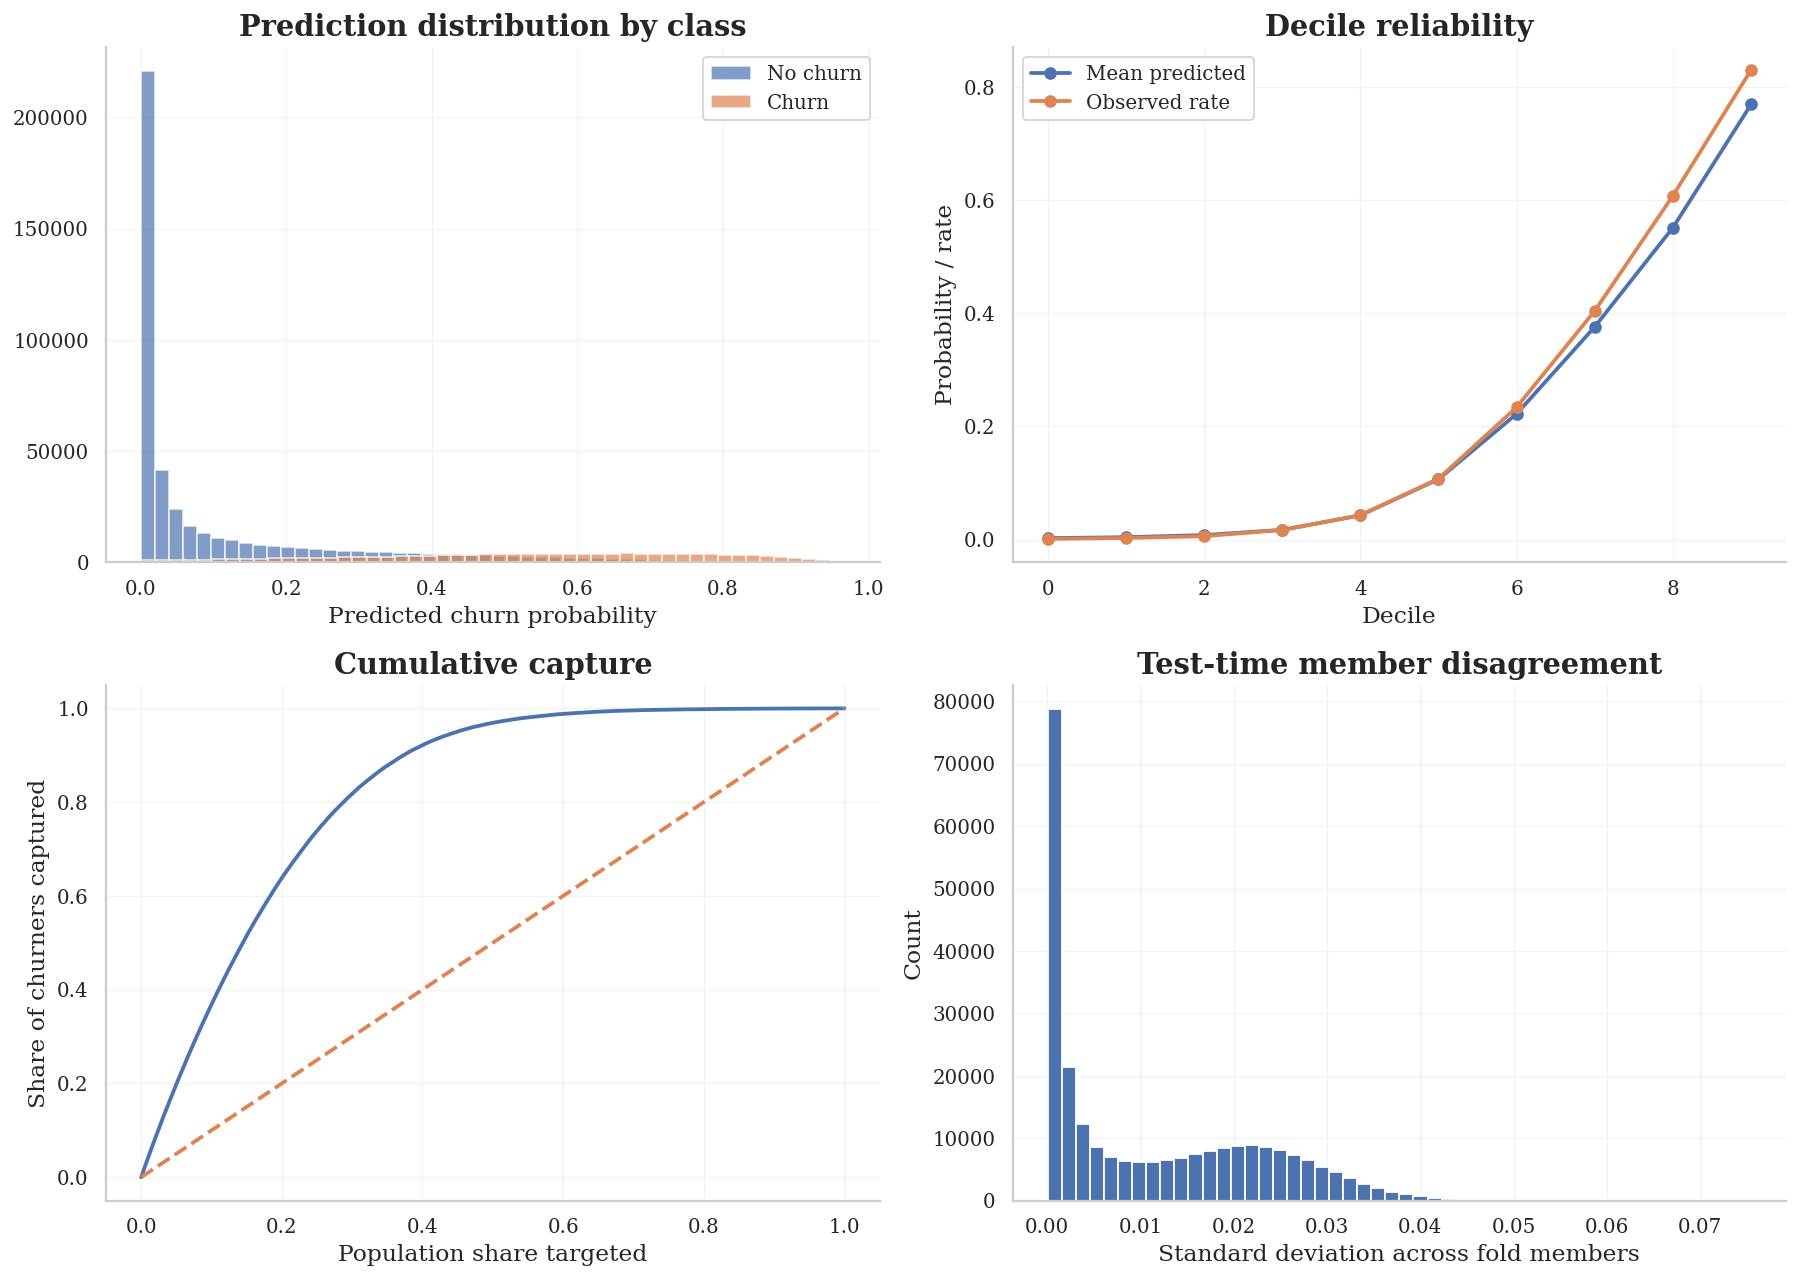

,bin,mean_pred,churn_rate,n,pred_min,pred_max
0,0,0.002330,0.001094,59420,0.000880,0.003107
1,1,0.004047,0.002710,59419,0.003107,0.005285
2,2,0.007776,0.005840,59419,0.005285,0.011012
3,3,0.017026,0.016829,59420,0.011013,0.025836
4,4,0.042658,0.042966,59419,0.025837,0.065962
5,5,0.106499,0.107390,59419,0.065962,0.156202
6,6,0.221997,0.233793,59420,0.156208,0.294355
7,7,0.375918,0.404180,59419,0.294356,0.460177
8,8,0.551160,0.607600,59419,0.460180,0.647994
9,9,0.768880,0.829670,59420,0.648000,0.966818


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(analysis_train.loc[analysis_train["y_true"] == 0, "realmlp_pred"], bins=50, alpha=0.7, label="No churn")
axes[0, 0].hist(analysis_train.loc[analysis_train["y_true"] == 1, "realmlp_pred"], bins=50, alpha=0.7, label="Churn")
axes[0, 0].set_title("Prediction distribution by class")
axes[0, 0].set_xlabel("Predicted churn probability")
axes[0, 0].legend()

dec_realmlp = make_decile_frame(bundle["y"], analysis_train["realmlp_pred"], n_bins=10)
axes[0, 1].plot(dec_realmlp["mean_pred"], marker="o", label="Mean predicted")
axes[0, 1].plot(dec_realmlp["churn_rate"], marker="o", label="Observed rate")
axes[0, 1].set_title("Decile reliability")
axes[0, 1].set_xlabel("Decile")
axes[0, 1].set_ylabel("Probability / rate")
axes[0, 1].legend()

cap_realmlp = cumulative_capture(bundle["y"], analysis_train["realmlp_pred"])
axes[1, 0].plot(cap_realmlp["population_share"], cap_realmlp["capture_rate"])
axes[1, 0].plot([0, 1], [0, 1], linestyle="--")
axes[1, 0].set_title("Cumulative capture")
axes[1, 0].set_xlabel("Population share targeted")
axes[1, 0].set_ylabel("Share of churners captured")

axes[1, 1].hist(analysis_test["member_std"], bins=50)
axes[1, 1].set_title("Test-time member disagreement")
axes[1, 1].set_xlabel("Standard deviation across fold members")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
savefig(cfg, "realmlp_01_core_diagnostics.png")
plt.show()

display(dec_realmlp)


## 4. Build reusable prediction functions for custom slices

The helper already provides replay for the original train/test split. For XAI work we also need predictions on modified input frames.

The next cell wraps the same preprocessing logic used by the helper so that we can:
- perturb rows,
- draw two-dimensional conditional slices,
- compute finite-difference sensitivities,
- run grouped ablations.

This cell does not modify the helper file. It only uses it as-is.


In [6]:
def prepare_custom_realmlp_df(raw_df, realmlp_bundle, cfg):
    df = raw_df.copy()
    if cfg.id_col in df.columns:
        df = df.drop(columns=[cfg.id_col]).copy()

    if cfg.target_col in df.columns:
        df[cfg.target_col] = (df[cfg.target_col] == "Yes").astype(int)

    df = FE_realmlp(df, cfg)

    for c in ["MonthlyCharges", "TotalCharges"]:
        for n_bins in ([100, 1000] if c == "MonthlyCharges" else [500, 4000]):
            kb = realmlp_bundle["kb_objects"][f"{c}_bin{n_bins}"]
            vals = df[c].values.reshape(-1, 1)
            df[f"{c}_bin{n_bins}"] = kb.transform(vals).flatten().astype(int)

    drop_cols = [c for c in realmlp_bundle["DROP"] if c in df.columns]
    df = df.drop(columns=drop_cols, errors="ignore")

    if "service_count" not in df.columns:
        from churn_analysis_helpers import REALMLP_SERVICE_COLS
        df["service_count"] = (df[REALMLP_SERVICE_COLS] == "Yes").sum(axis=1).astype("float32")

    category = realmlp_bundle["CATEGORY"]
    nums = realmlp_bundle["NUMS"]

    for c in category:
        if c not in df.columns:
            df[c] = "__missing__"
        mapping_info = realmlp_bundle["category_mappings"][c]
        mapping = mapping_info["mapping"]
        default = mapping_info["default"]
        df[c] = df[c].map(lambda x: mapping.get(x, default)).astype("int32")

    for c in nums:
        if c not in df.columns:
            df[c] = 0.0

    X_num = df[nums].values.astype(np.float32)
    X_cat = df[category].values.astype(np.int64)

    return df, X_num, X_cat


def build_realmlp_fold_cache(realmlp_bundle, cfg, embed_dim=10, n_ens=8):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_num = realmlp_bundle["X_num"]
    X_cat = realmlp_bundle["X_cat"]
    y_nn = realmlp_bundle["y_nn"]
    cat_dims_global = realmlp_bundle["cat_dims_global"]
    cols_to_encode = realmlp_bundle["cols_to_encode"]
    ckpts = load_realmlp_checkpoints(cfg)

    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=cfg.n_splits, shuffle=True, random_state=cfg.seed)

    cache = []
    for fold, ((train_idx, valid_idx), ckpt_path) in enumerate(zip(skf.split(X_num, y_nn), ckpts), start=1):
        X_num_train, X_cat_train, y_train = X_num[train_idx], X_cat[train_idx], y_nn[train_idx]

        te = TargetEncoder(target_type="binary", cv=5)
        if len(cols_to_encode) > 0:
            X_cat_train_encoded = te.fit_transform(X_cat_train[:, cols_to_encode], y_train)
        else:
            X_cat_train_encoded = np.zeros((len(train_idx), 0), dtype=np.float32)

        X_num_train_aug = np.concatenate([X_num_train, X_cat_train_encoded], axis=1)
        rssc = RobustScaleSmoothClipTransform().fit(X_num_train_aug)

        state = torch.load(ckpt_path, map_location=device)
        expected_n_num = int(state["num_embed.w1"].shape[1])

        model = RealMLP(
            input_dim=int(expected_n_num * 5 + sum([c if c <= 8 else embed_dim for c in cat_dims_global])),
            output_dim=2,
            cat_dims=cat_dims_global,
            n_numerical=expected_n_num,
            n_ens=n_ens,
            embed_dim=embed_dim,
            device=device,
        ).to(device)
        model.load_state_dict(state)
        model.eval()

        cache.append({
            "fold": fold,
            "train_idx": train_idx,
            "valid_idx": valid_idx,
            "te": te,
            "rssc": rssc,
            "model": model,
            "device": device,
        })
    return cache


def predict_realmlp_custom(raw_df, realmlp_bundle, cfg, fold_cache, eval_bs=8192):
    _, X_num_custom, X_cat_custom = prepare_custom_realmlp_df(raw_df, realmlp_bundle, cfg)
    cols_to_encode = realmlp_bundle["cols_to_encode"]

    preds = []
    member_preds = []
    for item in fold_cache:
        te = item["te"]
        rssc = item["rssc"]
        model = item["model"]
        device = item["device"]

        if len(cols_to_encode) > 0:
            X_cat_encoded = te.transform(X_cat_custom[:, cols_to_encode])
        else:
            X_cat_encoded = np.zeros((len(X_num_custom), 0), dtype=np.float32)

        X_num_aug = np.concatenate([X_num_custom, X_cat_encoded], axis=1)
        X_num_aug = rssc.transform(X_num_aug)

        X_num_t = torch.as_tensor(X_num_aug, dtype=torch.float32, device=device)
        X_cat_t = torch.as_tensor(X_cat_custom, dtype=torch.long, device=device)

        fold_probs = []
        with torch.no_grad():
            for start in range(0, len(raw_df), eval_bs):
                probs = model(X_num_t[start:start + eval_bs], X_cat_t[start:start + eval_bs]).mean(dim=1)[:, 1]
                fold_probs.append(probs.detach().cpu().numpy())
        fold_probs = np.concatenate(fold_probs, axis=0)
        preds.append(fold_probs)

        # Member-level predictions from the ensemble dimension
        with torch.no_grad():
            member_block = []
            for start in range(0, len(raw_df), eval_bs):
                prob_full = model(X_num_t[start:start + eval_bs], X_cat_t[start:start + eval_bs])[:, :, 1]
                member_block.append(prob_full.detach().cpu().numpy())
        member_block = np.concatenate(member_block, axis=0)
        member_preds.append(member_block)

    preds = np.vstack(preds)
    mean_pred = preds.mean(axis=0)

    member_preds = np.stack(member_preds, axis=0)   # fold x row x member
    flat_member_preds = member_preds.transpose(1, 0, 2).reshape(len(raw_df), -1)

    return {
        "mean_pred": mean_pred,
        "fold_pred_matrix": preds,
        "member_pred_matrix": flat_member_preds,
        "custom_X_num": X_num_custom,
        "custom_X_cat": X_cat_custom,
    }


fold_cache = build_realmlp_fold_cache(realmlp_bundle, cfg)
print("Cached folds:", len(fold_cache))


Cached folds: 10


## 5. Permutation importance on the replayed competition train set

For the neural model, permutation importance is a robust first-line global explanation because it does not require a tree-specific decomposition and respects the actual fitted predictor.


In [12]:
from sklearn.base import ClassifierMixin, BaseEstimator
from sklearn.inspection import permutation_importance

class RealMLPWrappedEstimator(ClassifierMixin, BaseEstimator):
    def __init__(self, engineered_df, realmlp_bundle, cfg, fold_cache):
        self.engineered_df = engineered_df.reset_index(drop=True).copy()
        self.realmlp_bundle = realmlp_bundle
        self.cfg = cfg
        self.fold_cache = fold_cache

    def fit(self, X, y=None):
        if y is not None:
            self.classes_ = np.unique(y)
        else:
            self.classes_ = np.array([0, 1], dtype=np.int32)
        self.n_features_in_ = X.shape[1]
        return self

    def predict_proba(self, X):
        df = self.engineered_df.loc[X.index].copy()
        df.loc[:, X.columns] = X.copy()
        out = predict_realmlp_custom_from_engineered(
            df,
            self.realmlp_bundle,
            self.cfg,
            self.fold_cache,
        )
        p1 = np.asarray(out["mean_pred"], dtype=np.float64)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(np.int32)


train_nn = realmlp_bundle["train_nn"].copy()
y_true = realmlp_bundle["y_nn"]

perm_features = realmlp_bundle["NUMS"][:]
perm_X = train_nn[perm_features].copy()

wrapped = RealMLPWrappedEstimator(train_nn, realmlp_bundle, cfg, fold_cache)
wrapped.fit(perm_X, y_true)

perm = permutation_importance(
    wrapped,
    perm_X,
    y_true,
    scoring="roc_auc",
    n_repeats=5,
    random_state=cfg.seed,
    n_jobs=1,
)

perm_imp = pd.DataFrame({
    "feature": perm_features,
    "mean_importance": perm.importances_mean,
    "std_importance": perm.importances_std,
}).sort_values("mean_importance", ascending=False)

display(perm_imp.head(25))

ax = perm_imp.head(20).sort_values("mean_importance").plot(
    x="feature",
    y="mean_importance",
    kind="barh",
    legend=False,
    figsize=(10, 8),
)
ax.set_title("Top 20 numerical features by permutation importance")
ax.set_xlabel("Mean AUC drop under permutation")
ax.set_ylabel("")
savefig(cfg, "realmlp_02_permutation_importance.png")
plt.show()

NameError: name 'predict_realmlp_custom_from_engineered' is not defined

## 6. Local finite-difference sensitivity

We approximate local sensitivity of the probability surface with finite differences:
$$
S_j(x) \approx \frac{p(x + h e_j) - p(x - h e_j)}{2h}.
$$

This is not a gradient through the full preprocessing graph. It is a practical response derivative on the reconstructed end-to-end predictor.


In [ ]:
def finite_difference_sensitivity(raw_df, features, realmlp_bundle, cfg, fold_cache, n_rows=2000):
    base_df = raw_df.iloc[:n_rows].copy().reset_index(drop=True)
    base_pred = predict_realmlp_custom(base_df, realmlp_bundle, cfg, fold_cache)["mean_pred"]

    rows = []
    for feat in features:
        s = pd.to_numeric(base_df[feat], errors="coerce")
        step = max(float(s.std(ddof=0)) * 0.05, 1e-3)

        plus_df = base_df.copy()
        minus_df = base_df.copy()
        plus_df[feat] = s + step
        minus_df[feat] = s - step

        plus_pred = predict_realmlp_custom(plus_df, realmlp_bundle, cfg, fold_cache)["mean_pred"]
        minus_pred = predict_realmlp_custom(minus_df, realmlp_bundle, cfg, fold_cache)["mean_pred"]

        sens = (plus_pred - minus_pred) / (2 * step)
        rows.append({
            "feature": feat,
            "mean_abs_sensitivity": float(np.mean(np.abs(sens))),
            "mean_signed_sensitivity": float(np.mean(sens)),
            "step": float(step),
        })
    return pd.DataFrame(rows).sort_values("mean_abs_sensitivity", ascending=False)

numeric_candidates = [f for f in realmlp_bundle["NUMS"] if f in raw_train_no_id.columns]
sens_df = finite_difference_sensitivity(raw_train_no_id, numeric_candidates[:20], realmlp_bundle, cfg, fold_cache, n_rows=1500)
display(sens_df.head(20))

plt.figure(figsize=(10, 8))
sens_df.head(15).sort_values("mean_abs_sensitivity").plot(
    x="feature", y="mean_abs_sensitivity", kind="barh", legend=False
)
plt.title("Finite-difference sensitivity: top features")
plt.xlabel("Mean absolute local sensitivity")
savefig(cfg, "realmlp_03_finite_difference_sensitivity.png")
plt.show()


## 7. Grouped categorical ablation

For the categorical branch we use grouped ablations. A group is neutralised by setting its columns to a reference category profile and measuring the induced probability shift.

This directly answers which categorical families the neural model is leaning on most.


In [ ]:
def mode_value(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if len(m) else s.iloc[0]

cat_groups = {
    "contract_payment": ["Contract", "PaymentMethod", "PaperlessBilling"],
    "internet_support": ["InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"],
    "streaming_phone": ["PhoneService", "MultipleLines", "StreamingTV", "StreamingMovies"],
    "household": ["gender", "SeniorCitizen", "Partner", "Dependents"],
}

base_rows = raw_train_no_id.iloc[:3000].copy().reset_index(drop=True)
base_pred = predict_realmlp_custom(base_rows, realmlp_bundle, cfg, fold_cache)["mean_pred"]

ablation_rows = []
for group_name, cols in cat_groups.items():
    present = [c for c in cols if c in base_rows.columns]
    if not present:
        continue
    tmp = base_rows.copy()
    for c in present:
        tmp[c] = mode_value(base_rows[c])
    abl_pred = predict_realmlp_custom(tmp, realmlp_bundle, cfg, fold_cache)["mean_pred"]
    delta = base_pred - abl_pred
    ablation_rows.append({
        "group": group_name,
        "mean_abs_delta": float(np.mean(np.abs(delta))),
        "mean_signed_delta": float(np.mean(delta)),
        "max_abs_delta": float(np.max(np.abs(delta))),
    })

ablation_df = pd.DataFrame(ablation_rows).sort_values("mean_abs_delta", ascending=False)
display(ablation_df)

plt.figure(figsize=(9, 5))
ablation_df.sort_values("mean_abs_delta").plot(x="group", y="mean_abs_delta", kind="barh", legend=False)
plt.title("Grouped categorical ablation")
plt.xlabel("Mean absolute probability shift")
savefig(cfg, "realmlp_04_grouped_ablation.png")
plt.show()


## 8. Conditional decision surfaces

For selected numerical feature pairs, we visualise two-dimensional conditional slices:
$$
(x_i, x_j) \mapsto p_{\text{mlp}}(x_i, x_j, \tilde{x}_{-ij}).
$$

Compared with the tree model, these surfaces should be smoother and more curved if the neural representation is interpolating rather than thresholding.


In [ ]:
def make_reference_raw_row(raw_df):
    ref = {}
    for c in raw_df.columns:
        if c == cfg.target_col:
            continue
        s = raw_df[c]
        if pd.api.types.is_numeric_dtype(s):
            ref[c] = float(pd.to_numeric(s, errors="coerce").median())
        else:
            ref[c] = mode_value(s.astype(str))
    return pd.Series(ref)

def plot_realmlp_surface(raw_df, feature_x, feature_y, grid_n=60, q_low=0.02, q_high=0.98):
    ref = make_reference_raw_row(raw_df)
    xs = np.linspace(pd.to_numeric(raw_df[feature_x], errors="coerce").quantile(q_low),
                     pd.to_numeric(raw_df[feature_x], errors="coerce").quantile(q_high),
                     grid_n)
    ys = np.linspace(pd.to_numeric(raw_df[feature_y], errors="coerce").quantile(q_low),
                     pd.to_numeric(raw_df[feature_y], errors="coerce").quantile(q_high),
                     grid_n)

    mesh_parts = []
    for yv in ys:
        tmp = pd.DataFrame([ref] * len(xs))
        tmp[feature_x] = xs
        tmp[feature_y] = yv
        mesh_parts.append(tmp)
    mesh = pd.concat(mesh_parts, axis=0, ignore_index=True)

    out = predict_realmlp_custom(mesh, realmlp_bundle, cfg, fold_cache)
    z = out["mean_pred"].reshape(len(ys), len(xs))

    fig, ax = plt.subplots(figsize=(8, 6))
    cf = ax.contourf(xs, ys, z, levels=20)
    ax.contour(xs, ys, z, levels=[0.5], linewidths=2)
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_title(f"Conditional probability surface: {feature_x} vs {feature_y}")
    plt.colorbar(cf, ax=ax, label="Predicted churn probability")
    return fig, ax

surface_features = [
    ("tenure", "MonthlyCharges"),
    ("MonthlyCharges", "TotalCharges"),
    ("tenure", "x2"),
    ("x1_0", "x2"),
]

for a, b in surface_features:
    if a in raw_train_no_id.columns and b in raw_train_no_id.columns:
        fig, ax = plot_realmlp_surface(raw_train_no_id, a, b)
        savefig(cfg, f"realmlp_surface_{a}_{b}.png".replace("/", "_").replace(" ", "_"))
        plt.show()


## 9. ICE-style slices for the neural predictor

Because `PartialDependenceDisplay` does not know how to call this custom replayed ensemble directly, we compute the slices ourselves.

For each feature, the plot shows:
- multiple individual conditional expectation curves,
- the average conditional response.

Smooth, curved trajectories indicate genuinely smooth response geometry.


In [ ]:
def custom_ice_curves(raw_df, feature, n_rows=60, grid_n=50):
    subset = raw_df.iloc[:n_rows].copy().reset_index(drop=True)
    grid = np.linspace(
        pd.to_numeric(raw_df[feature], errors="coerce").quantile(0.02),
        pd.to_numeric(raw_df[feature], errors="coerce").quantile(0.98),
        grid_n,
    )

    curves = []
    for i in range(len(subset)):
        row = subset.iloc[[i]].copy()
        tmp_list = []
        for v in grid:
            rr = row.copy()
            rr[feature] = v
            tmp_list.append(rr)
        tmp = pd.concat(tmp_list, axis=0, ignore_index=True)
        pred = predict_realmlp_custom(tmp, realmlp_bundle, cfg, fold_cache)["mean_pred"]
        curves.append(pred)
    curves = np.vstack(curves)
    return grid, curves

for feat in [f for f in ["tenure", "MonthlyCharges", "TotalCharges", "x2"] if f in raw_train_no_id.columns]:
    grid, curves = custom_ice_curves(raw_train_no_id, feat, n_rows=40, grid_n=40)
    fig, ax = plt.subplots(figsize=(8, 5))
    for i in range(min(25, curves.shape[0])):
        ax.plot(grid, curves[i], alpha=0.25)
    ax.plot(grid, curves.mean(axis=0), linewidth=3, label="Mean response")
    ax.set_title(f"ICE-style conditional slices: {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Predicted churn probability")
    ax.legend()
    savefig(cfg, f"realmlp_ice_{feat}.png".replace("/", "_").replace(" ", "_"))
    plt.show()


## 10. Disagreement and uncertainty structure

Fold-model averaging gives us a natural uncertainty proxy: disagreement across fold-members.

We inspect where disagreement is highest and whether high disagreement aligns with higher error.


In [ ]:
oof_fold_pred = replay["realmlp_fold_pred_matrix"]
analysis_train["fold_std"] = oof_fold_pred.std(axis=1)
analysis_train["fold_range"] = oof_fold_pred.max(axis=1) - oof_fold_pred.min(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(analysis_train["realmlp_pred"], analysis_train["fold_std"], alpha=0.3)
axes[0].set_title("Prediction vs fold disagreement")
axes[0].set_xlabel("Predicted probability")
axes[0].set_ylabel("Fold standard deviation")

axes[1].scatter(analysis_train["fold_std"], analysis_train["abs_error"], alpha=0.3)
axes[1].set_title("Fold disagreement vs absolute error")
axes[1].set_xlabel("Fold standard deviation")
axes[1].set_ylabel("Absolute error")

plt.tight_layout()
savefig(cfg, "realmlp_05_disagreement_vs_error.png")
plt.show()

uncertainty_summary = analysis_train.groupby(pd.qcut(analysis_train["fold_std"], q=5, duplicates="drop")).agg(
    mean_pred=("realmlp_pred", "mean"),
    observed_rate=("y_true", "mean"),
    mean_abs_error=("abs_error", "mean"),
    n=("y_true", "size"),
)
display(uncertainty_summary)


## 11. Local case studies

We create representative local diagnostics for:
- extreme TP,
- extreme TN,
- high-confidence FP,
- low-score FN.

For the neural model, the most honest local explanation is a local perturbation report:
- base prediction,
- top finite-difference sensitivities for numerical variables,
- effect of grouped categorical ablations for that row.


In [ ]:
def local_numeric_sensitivity_for_row(raw_df_single, features, n_top=12):
    base = predict_realmlp_custom(raw_df_single, realmlp_bundle, cfg, fold_cache)["mean_pred"][0]
    rows = []
    for feat in features:
        s = pd.to_numeric(raw_train_no_id[feat], errors="coerce")
        step = max(float(s.std(ddof=0)) * 0.05, 1e-3)
        plus = raw_df_single.copy()
        minus = raw_df_single.copy()
        plus[feat] = pd.to_numeric(plus[feat], errors="coerce") + step
        minus[feat] = pd.to_numeric(minus[feat], errors="coerce") - step
        p_plus = predict_realmlp_custom(plus, realmlp_bundle, cfg, fold_cache)["mean_pred"][0]
        p_minus = predict_realmlp_custom(minus, realmlp_bundle, cfg, fold_cache)["mean_pred"][0]
        rows.append({
            "feature": feat,
            "local_abs_sensitivity": abs((p_plus - p_minus) / (2 * step)),
            "local_signed_sensitivity": (p_plus - p_minus) / (2 * step),
        })
    out = pd.DataFrame(rows).sort_values("local_abs_sensitivity", ascending=False).head(n_top)
    return base, out

candidate_rows = []
for q in [
    analysis_train.query("case_type == 'TP'").sort_values("realmlp_pred", ascending=False),
    analysis_train.query("case_type == 'TN'").sort_values("realmlp_pred", ascending=True),
    analysis_train.query("case_type == 'FP'").sort_values("realmlp_pred", ascending=False),
    analysis_train.query("case_type == 'FN'").sort_values("realmlp_pred", ascending=True),
]:
    if len(q):
        candidate_rows.append(int(q.index[0]))

for ridx in candidate_rows:
    raw_row = raw_train_no_id.iloc[[ridx]].copy()
    base_pred, local_sens = local_numeric_sensitivity_for_row(
        raw_row,
        [f for f in ["tenure", "MonthlyCharges", "TotalCharges", "x1_0", "x1_1", "x2", "x3", "x4"] if f in raw_row.columns]
    )
    print({
        "row_index": ridx,
        "y_true": int(analysis_train.loc[ridx, "y_true"]),
        "pred": float(base_pred),
        "case_type": analysis_train.loc[ridx, "case_type"],
    })
    display(local_sens)


## 12. Export tables

This section writes the central report artefacts for the RealMLP study.


In [ ]:
outdir = Path(cfg.output_dir)

analysis_train.to_csv(outdir / "realmlp_analysis_train.csv", index=False)
analysis_test.to_csv(outdir / "realmlp_analysis_test.csv", index=False)
replay["realmlp_fold_metrics_df"].to_csv(outdir / "realmlp_fold_metrics.csv", index=False)
replay["schema_df"].to_csv(outdir / "realmlp_schema_check.csv", index=False)
dec_realmlp.to_csv(outdir / "realmlp_deciles.csv", index=False)
perm_imp.to_csv(outdir / "realmlp_permutation_importance.csv", index=False)
sens_df.to_csv(outdir / "realmlp_finite_difference_sensitivity.csv", index=False)
ablation_df.to_csv(outdir / "realmlp_grouped_ablation.csv", index=False)
uncertainty_summary.to_csv(outdir / "realmlp_uncertainty_summary.csv")

summary = {
    "oof_auc": float(replay["realmlp_oof_auc"]),
    "oof_logloss": float(log_loss(bundle["y"], replay["realmlp_oof"])),
    "oof_brier": float(brier_score_loss(bundle["y"], replay["realmlp_oof"])),
    "n_numeric_features": int(schema["numeric_count"]),
    "n_categorical_features": int(schema["categorical_count"]),
    "top10_permutation_importance": perm_imp.head(10).set_index("feature")["mean_importance"].to_dict(),
    "top10_finite_difference_sensitivity": sens_df.head(10).set_index("feature")["mean_abs_sensitivity"].to_dict(),
}
(outdir / "realmlp_xai_summary.json").write_text(json.dumps(summary, indent=2))
summary
